In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.qaoa_utils import QAOASolver, evaluate_energy

import numpy as np
import qubovert

import pcbo_utils
from qiskit.quantum_info import SparsePauliOp

In [2]:
n_qubits = 8
feature_set, feature_to_idx, first_corr_arr, second_corr_arr, third_corr_arr = pcbo_utils.load_features_and_corr_files(f'sampled_{n_qubits}_features_subproblem_1')

pcbo_obj = pcbo_utils.create_three_body_cubo(
    feature_set,
    first_corr_arr,
    second_corr_arr,
    third_corr_arr,
    feature_to_idx,
    select_n_features=4,
)

pubo = {key: float(value) for key, value in pcbo_obj.to_pubo().items()}

In [3]:
def convert_pubo_to_ising(hypergraph: dict) -> list[tuple[str, float]]:
    """Convert a hypergraph dictionary to a list of Pauli strings with weights."""
    n = n_qubits # Number of qubits
    pauli_list = []

    for edge, weight in hypergraph.items():
        if edge:  # Ensure the edge is not empty
            # Create a Pauli string with "I" for all qubits
            paulis = ["I"] * n
            # Replace "I" with "Z" for qubits in the edge
            for node in edge:
                paulis[node] = "Z"
            # Append the reversed Pauli string and weight to the list
            pauli_list.append(("".join(paulis[::-1]), weight))

    return pauli_list

max_cut_paulis = convert_pubo_to_ising(pubo)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
cost_hamiltonian

SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII', 'IZIIIZII', 'ZIIIIZII', 'IIIZZIII', 'IIZIZIII', 'IZIIZIII', 'ZIIIZIII', 'IIZZIIII', 'IZIZIIII', 'ZIIZIIII', 'IZZIIIII', 'ZIZIIIII', 'ZZIIIIII', 'IIIIIZZZ', 'IIIIZIZZ', 'IIIZIIZZ', 'IIZIIIZZ', 'IZIIIIZZ', 'ZIIIIIZZ', 'IIIIZZIZ', 'IIIZIZIZ', 'IIZIIZIZ', 'IZIIIZIZ', 'ZIIIIZIZ', 'IIIZZIIZ', 'IIZIZIIZ', 'IZIIZIIZ', 'ZIIIZIIZ', 'IIZZIIIZ', 'IZIZIIIZ', 'ZIIZIIIZ', 'IZZIIIIZ', 'ZIZIIIIZ', 'ZZIIIIIZ', 'IIIIZZZI', 'IIIZIZZI', 'IIZIIZZI', 'IZIIIZZI', 'ZIIIIZZI', 'IIIZZIZI', 'IIZIZIZI', 'IZIIZIZI', 'ZIIIZIZI', 'IIZZIIZI', 'IZIZIIZI', 'ZIIZIIZI', 'IZZIIIZI', 'ZIZIIIZI', 'ZZIIIIZI', 'IIIZZZII', 'IIZIZZII', 'IZIIZZII', 'ZIIIZZII', 'IIZZIZII', 'IZIZIZII', 'ZIIZIZII', 'IZZIIZII', 'ZIZIIZII', 'ZZIIIZII', '

In [4]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
circuit

In [5]:
teague_qaoa = QAOASolver(cost_hamiltonian,circuit)
teague_qaoa.prepare_circuit()

In [6]:
# we can perform CAFQA by using the main optimization function "claptonize"
teague_qaoa.run_CAFQA(n_gens=10)

STARTING ROUND 0


started GA at id 1 with 1 procs
started GA at id None with 1 procs

started GA at id 2 with 1 procs

started GA at id 3 with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=ada

In [7]:
teague_qaoa.energy_best

np.float64(-9000.462603108466)

In [8]:
# Solve with classical Eigensolver for comparison
exact_solution = teague_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -20006.446190868308


In [9]:
cafqa_angles = [param * np.pi/2 for param in teague_qaoa.ks_best]

In [10]:
energies = [evaluate_energy(teague_qaoa.pcirc,cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -8922.961236938645


In [11]:
# Random Initalization
random_angles = np.random.random(len(teague_qaoa.ks_best))
random_energies = [evaluate_energy(teague_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 4073.333671087031


In [12]:
cafqa_result,cafqa_iteration_vals = teague_qaoa.run_qaoa(cafqa_angles,max_iters=10)
random_result,random_iteration_vals = teague_qaoa.run_qaoa(random_angles,max_iters=10)

In [13]:
cafqa_result

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -9301.671137522877
       x: [ 5.712e+00  4.712e+00 ...  1.571e+00  1.571e+00]
    nfev: 10
   maxcv: 0.0

In [14]:
# Solve with classical Eigensolver for comparison
eigensolver = NumPyMinimumEigensolver()
exact_solution = eigensolver.compute_minimum_eigenvalue(cost_hamiltonian).eigenvalue.real
print("Exact Energy from Eigensolver:", exact_solution)

Exact Energy from Eigensolver: -20006.446190868308


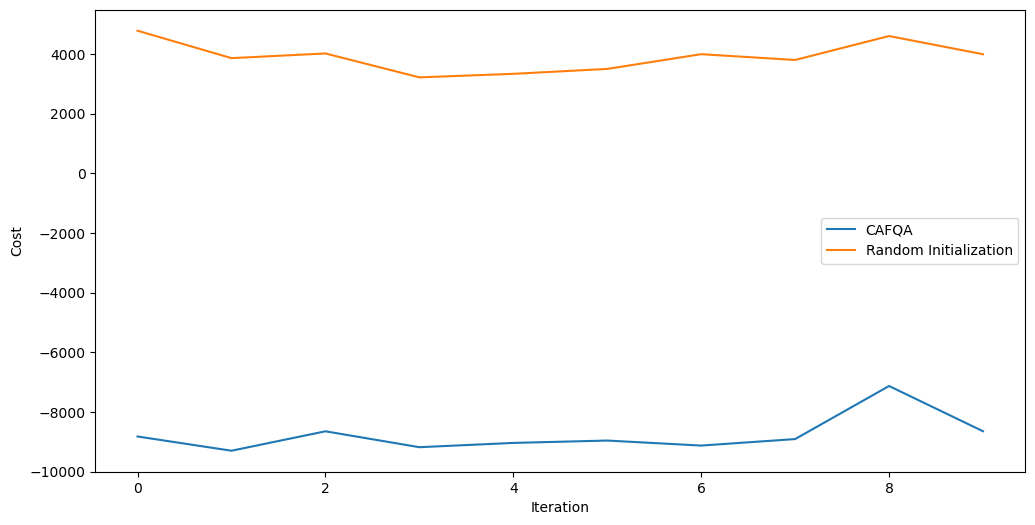

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()